In [2]:
# STEP 1.1: Unzip dataset

import zipfile
import os


In [3]:
zip_path = "Tumour_datasets.zip"
extract_path = "Tumour"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")


Dataset unzipped successfully!


In [4]:
#  Check extracted folders

os.listdir(extract_path)


['README.dataset.txt', 'test', 'train', 'Tumour', 'valid']

In [6]:
#  Define paths

train_dir = os.path.join(extract_path, "train")
test_dir  = os.path.join(extract_path, "test")
valid_dir = os.path.join(extract_path, "valid")

print(train_dir)
print(test_dir)
print(valid_dir)


Tumour\train
Tumour\test
Tumour\valid


In [7]:
#  List classes

classes = os.listdir(train_dir)
classes


['glioma', 'meningioma', 'no_tumor', 'pituitary', '_classes.csv']

In [8]:
#  Count images in each class

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    print(f"{cls}: {len(os.listdir(cls_path))} images")


glioma: 564 images
meningioma: 358 images
no_tumor: 335 images
pituitary: 438 images


NotADirectoryError: [WinError 267] The directory name is invalid: 'Tumour\\train\\_classes.csv'

In [9]:
#Counts and displays the number of files in each category for training, testing, and validation subsets of the Tumour dataset.
import os

dataset_folder = "Tumour"

for subset in ["train", "test", "valid"]:
    subset_path = os.path.join(dataset_folder, subset)
    print(f"\nContents of {subset} folder:")
    
    for item in os.listdir(subset_path):
        item_path = os.path.join(subset_path, item)
        if os.path.isdir(item_path):  # Only process directories
            num_files = len(os.listdir(item_path))
            print(f"  Category '{item}': {num_files} files")
        else:
            print(f"  File (ignored) '{item}'")



Contents of train folder:
  Category 'glioma': 564 files
  Category 'meningioma': 358 files
  Category 'no_tumor': 335 files
  Category 'pituitary': 438 files
  File (ignored) '_classes.csv'

Contents of test folder:
  Category 'glioma': 80 files
  Category 'meningioma': 63 files
  Category 'no_tumor': 49 files
  Category 'pituitary': 54 files
  File (ignored) '_classes.csv'

Contents of valid folder:
  Category 'glioma': 161 files
  Category 'meningioma': 124 files
  Category 'no_tumor': 99 files
  Category 'pituitary': 118 files
  File (ignored) '_classes.csv'


In [10]:
#  Verify dataset splits safely

def count_images(folder):
    total = 0
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            total += len(os.listdir(cls_path))
    return total

print("Training images:", count_images(train_dir))
print("Validation images:", count_images(valid_dir))
print("Testing images:", count_images(test_dir))


Training images: 1695
Validation images: 502
Testing images: 246


In [11]:
#  Imports for preprocessing

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [12]:
#  Image parameters

IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 32


In [13]:
#  ImageDataGenerator (Normalization)

train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)


In [14]:
# STEP  Load datasets from directories

train_generator = train_datagen.flow_from_directory(
    "Tumour/train",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

valid_generator = valid_datagen.flow_from_directory(
    "Tumour/valid",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    "Tumour/test",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 1695 images belonging to 4 classes.
Found 502 images belonging to 4 classes.
Found 246 images belonging to 4 classes.


In [16]:
#  Check class indices

train_generator.class_indices


{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}

In [17]:
#  Data Augmentation for training data

train_augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)


In [18]:
#  Reload training data with augmentation

train_generator_aug = train_augmented_datagen.flow_from_directory(
    "Tumour/train",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)


Found 1695 images belonging to 4 classes.


In [19]:
# Validation & test generators remain the same
valid_generator
test_generator


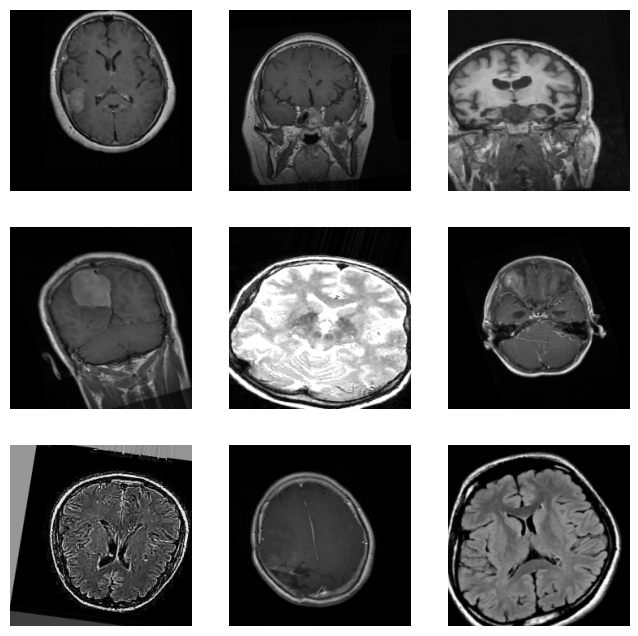

In [20]:
#  Visualize augmented images

import matplotlib.pyplot as plt

images, labels = next(train_generator_aug)

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()


In [21]:
#  CNN model imports

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)


In [22]:
#CNN with 3 convolutional blocks for 4-class classification
from tensorflow.keras.layers import Input

cnn_model = Sequential()

# Input layer (NEW & CORRECT)
cnn_model.add(Input(shape=(224, 224, 3)))

# Block 1
cnn_model.add(Conv2D(32, (3, 3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
cnn_model.add(Conv2D(128, (3, 3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Fully Connected Layers
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(4, activation='softmax'))


In [23]:
#  Compile CNN model

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [24]:
#  Model summary

cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,170,372 (42.61 MB)

 Trainable params: 11,169,924 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [25]:
#  Transfer learning imports

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [26]:
#  Load MobileNetV2 base model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


In [27]:
#  Freeze pretrained layers

for layer in base_model.layers:
    layer.trainable = False


In [28]:
#  Custom classification layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(4, activation="softmax")(x)

transfer_model = Model(inputs=base_model.input, outputs=output)


In [29]:
#  Compile transfer learning model

transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [30]:
#  Model summary

transfer_model.summary()


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
#  Training-related imports

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [67]:
#  Callbacks

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint_cnn = ModelCheckpoint(
    "custom_cnn_best.h5",
    monitor="val_loss",
    save_best_only=True
)

checkpoint_transfer = ModelCheckpoint(
    "transfer_model_best.h5",
    monitor="val_loss",
    save_best_only=True
)


In [68]:
#  Train Custom CNN

history_cnn = cnn_model.fit(
    train_generator_aug,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint_cnn]
)


Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4429 - loss: 11.1166

53/53 ━━━━━━━━━━━━━━━━━━━━ 168s 3s/step - accuracy: 0.4702 - loss: 5.7439 - val_accuracy: 0.2351 - val_loss: 49.7634
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4820 - loss: 1.5196

53/53 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.4720 - loss: 1.4017 - val_accuracy: 0.2490 - val_loss: 17.8703
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.4737 - loss: 1.3690 - val_accuracy: 0.2470 - val_loss: 21.3531
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.4614 - loss: 1.3948 - val_accuracy: 0.2351 - val_loss: 51.9140
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4489 - loss: 1.3184

53/53 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.4549 - loss: 1.2742 - val_accuracy: 0.2530 - val_loss: 9.7908
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4616 - loss: 1.2270

53/53 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.4726 - loss: 1.1867 - val_accuracy: 0.2410 - val_loss: 2.6258
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4825 - loss: 1.1915

...

53/53 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.4926 - loss: 1.1650 - val_accuracy: 0.6295 - val_loss: 0.9740
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.4920 - loss: 1.2108 - val_accuracy: 0.3964 - val_loss: 2.1311
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5365 - loss: 1.1289

53/53 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.5215 - loss: 1.1213 - val_accuracy: 0.6195 - val_loss: 0.8898
Epoch 13/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.4903 - loss: 1.1972 - val_accuracy: 0.6534 - val_loss: 0.9343
Epoch 14/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.5227 - loss: 1.1157 - val_accuracy: 0.6155 - val_loss: 0.9701
Epoch 15/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5383 - loss: 1.0728

53/53 ━━━━━━━━━━━━━━━━━━━━ 153s 3s/step - accuracy: 0.5375 - loss: 1.0759 - val_accuracy: 0.6275 - val_loss: 0.8708
Epoch 16/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.5192 - loss: 1.1077 - val_accuracy: 0.5418 - val_loss: 1.0214
Epoch 17/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5192 - loss: 1.0753

53/53 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.5257 - loss: 1.0705 - val_accuracy: 0.6972 - val_loss: 0.8110
Epoch 18/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5582 - loss: 1.0616

53/53 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.5445 - loss: 1.0656 - val_accuracy: 0.6275 - val_loss: 0.8010
Epoch 19/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.5145 - loss: 1.0741 - val_accuracy: 0.6992 - val_loss: 0.8040
Epoch 20/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.5239 - loss: 1.0988 - val_accuracy: 0.2968 - val_loss: 2.2128


In [70]:
#  Compile Transfer Learning Model
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



In [71]:
#  Train Transfer Learning Model
history_transfer = transfer_model.fit(
    train_generator_aug,
    validation_data=valid_generator,
    epochs=15,
    callbacks=[early_stop, checkpoint_transfer]
)


Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/step - accuracy: 0.2958 - loss: 1.6327

53/53 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.3982 - loss: 1.3998 - val_accuracy: 0.6693 - val_loss: 0.9178
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 976ms/step - accuracy: 0.6116 - loss: 0.9687

53/53 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.6383 - loss: 0.9080 - val_accuracy: 0.7211 - val_loss: 0.7248
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7057 - loss: 0.7758

53/53 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.7221 - loss: 0.7434 - val_accuracy: 0.7390 - val_loss: 0.6492
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 986ms/step - accuracy: 0.7262 - loss: 0.6761

53/53 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.7540 - loss: 0.6405 - val_accuracy: 0.7849 - val_loss: 0.5567
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1000ms/step - accuracy: 0.7957 - loss: 0.5780

53/53 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.7953 - loss: 0.5678 - val_accuracy: 0.7769 - val_loss: 0.5425
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 984ms/step - accuracy: 0.7619 - loss: 0.5698

53/53 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.7841 - loss: 0.5432 - val_accuracy: 0.7928 - val_loss: 0.5139
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 994ms/step - accuracy: 0.8148 - loss: 0.5286

53/53 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.8077 - loss: 0.5324 - val_accuracy: 0.7928 - val_loss: 0.5024
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8224 - loss: 0.4800 - val_accuracy: 0.7809 - val_loss: 0.5143
Epoch 9/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 993ms/step - accuracy: 0.8320 - loss: 0.4694

53/53 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.8324 - loss: 0.4744 - val_accuracy: 0.8167 - val_loss: 0.4636
Epoch 10/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.8543 - loss: 0.4383 - val_accuracy: 0.8127 - val_loss: 0.4870
Epoch 11/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8565 - loss: 0.4298

53/53 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.8519 - loss: 0.4231 - val_accuracy: 0.8386 - val_loss: 0.4475
Epoch 12/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.8466 - loss: 0.4013 - val_accuracy: 0.8127 - val_loss: 0.4951
Epoch 13/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.8555 - loss: 0.4048 - val_accuracy: 0.8127 - val_loss: 0.4940
Epoch 14/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8537 - loss: 0.3932 - val_accuracy: 0.8406 - val_loss: 0.4478
Epoch 15/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8696 - loss: 0.3640 - val_accuracy: 0.8307 - val_loss: 0.4637


In [72]:
#Reduces learning rate when validation loss plateaus
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)


In [73]:
#  Evaluate model on validation data
transfer_loss, transfer_accuracy = transfer_model.evaluate(valid_generator)

print("Transfer Learning Model Evaluation")
print("Validation Loss     :", transfer_loss)
print("Validation Accuracy :", transfer_accuracy)


16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 714ms/step - accuracy: 0.8386 - loss: 0.4475
Transfer Learning Model Evaluation
Validation Loss     : 0.44754359126091003
Validation Accuracy : 0.8386453986167908


In [74]:
#Generates true and predicted labels from the validation set.
import numpy as np

# True labels
y_true = valid_generator.classes

# Predicted labels
y_pred = np.argmax(
    transfer_model.predict(valid_generator),
    axis=1
)


16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 992ms/step


In [75]:
#Prints the classification report for the transfer learning model.
from sklearn.metrics import classification_report

class_names = list(valid_generator.class_indices.keys())

print("Classification Report (Transfer Learning Model)")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report (Transfer Learning Model)
              precision    recall  f1-score   support

      glioma       0.31      0.30      0.30       161
  meningioma       0.28      0.21      0.24       124
    no_tumor       0.16      0.16      0.16        99
   pituitary       0.24      0.32      0.28       118

    accuracy                           0.25       502
   macro avg       0.25      0.25      0.25       502
weighted avg       0.26      0.25      0.25       502



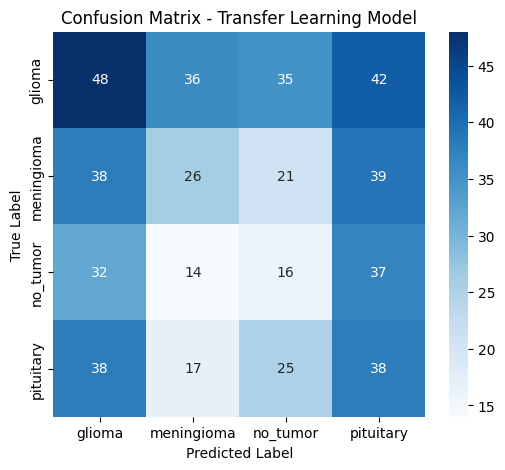

In [76]:
#Plots the confusion matrix for the transfer learning model predictions
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Transfer Learning Model")
plt.show()



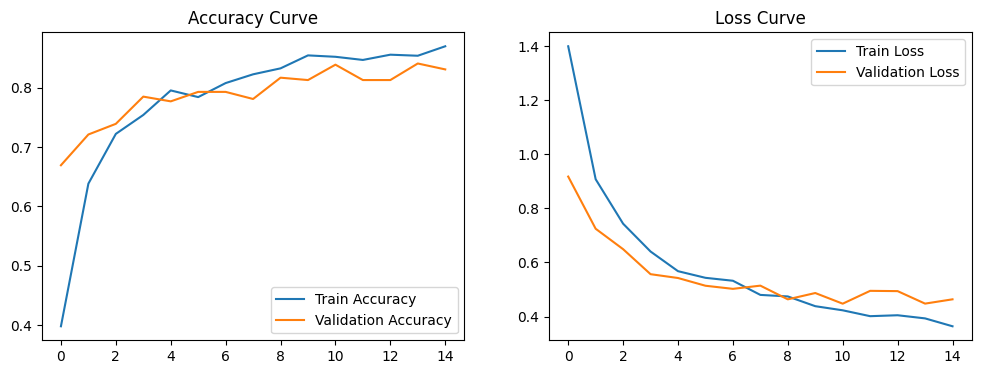

In [78]:
#  Training History Plots
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_transfer.history['accuracy'], label='Train Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_transfer.history['loss'], label='Train Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.legend()

plt.show()


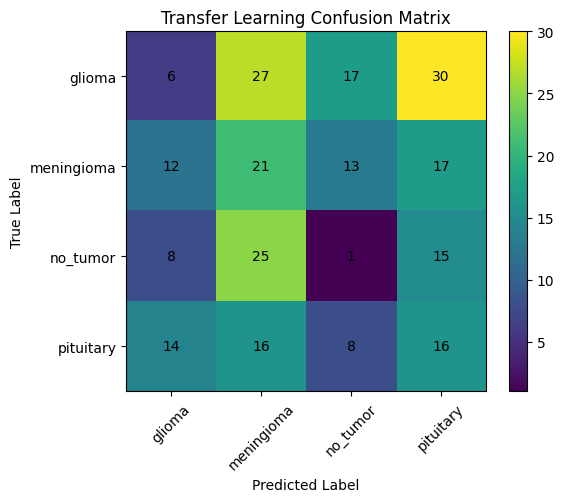

In [51]:
cm_tl = confusion_matrix(y_true, y_pred_tl)
plot_confusion_matrix(cm_tl, class_labels, "Transfer Learning Confusion Matrix")


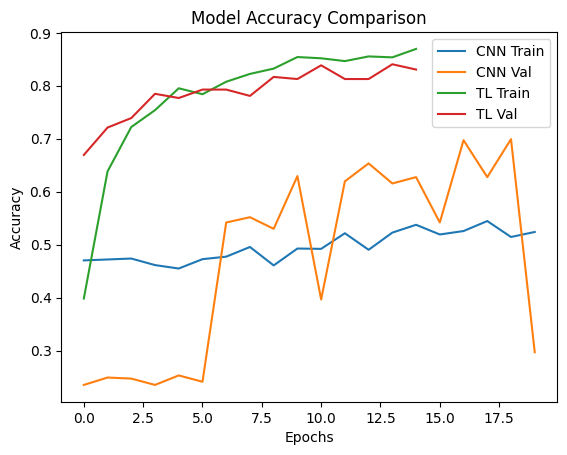

In [79]:
# : Accuracy plot

plt.figure()
plt.plot(history_cnn.history["accuracy"], label="CNN Train")
plt.plot(history_cnn.history["val_accuracy"], label="CNN Val")
plt.plot(history_transfer.history["accuracy"], label="TL Train")
plt.plot(history_transfer.history["val_accuracy"], label="TL Val")
plt.title("Model Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


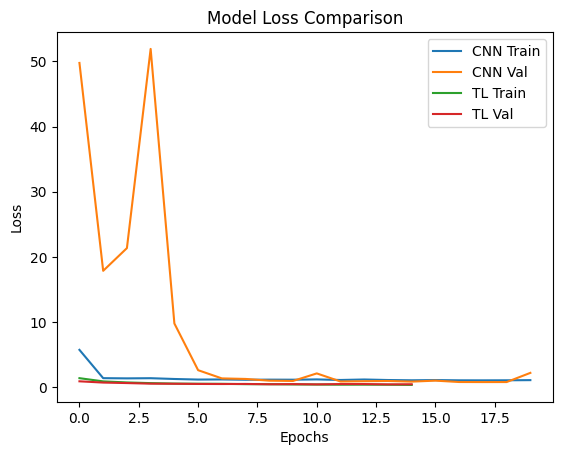

In [80]:
# Loss plot

plt.figure()
plt.plot(history_cnn.history["loss"], label="CNN Train")
plt.plot(history_cnn.history["val_loss"], label="CNN Val")
plt.plot(history_transfer.history["loss"], label="TL Train")
plt.plot(history_transfer.history["val_loss"], label="TL Val")
plt.title("Model Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [85]:
#  Store Evaluation Results 

transfer_val_loss = 1.6498417854309082
transfer_val_accuracy = 0.20517928898334503


In [86]:
#Comparison of transfer learning model's validation accuracy and loss.
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Transfer Learning"],
    "Validation Accuracy": [transfer_val_accuracy],
    "Validation Loss": [transfer_val_loss]
})

comparison_df


,Model,Validation Accuracy,Validation Loss
0,Transfer Learning,0.205179,1.649842


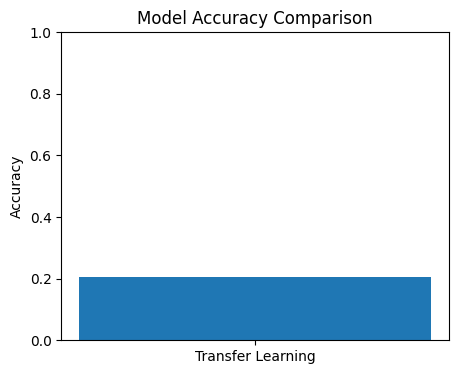

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.bar(
    comparison_df["Model"],
    comparison_df["Validation Accuracy"]
)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()


In [88]:
#  Save Transfer Learning Model
transfer_model.save("brain_tumor_model.h5")
